# WGAN-GP NON LINEAR LAYER

This notebook trains a **Wasserstein GAN with Gradient Penalty (WGAN-GP)** on multifractal texture data stored as `.mat` files.  
Each sample contains a 2-channel (512×512) complex-valued field loaded via `scipy.io`. It will be cutted to 128x128

**Pipeline overview:**
1. Load `.mat` files in parallel → HuggingFace `Dataset`
2. Apply an on-the-fly transform to produce 2-channel PyTorch tensors
3. Train a WGAN-GP (Generator + Critic) with Wasserstein loss + **gradient penalty**
4. Save generated textures as `.mat` for OCTAVE analysis

**Key differences vs vanilla WGAN (weight clipping):**
- Critic weights are **not clipped** — instead a **gradient penalty** enforces the Lipschitz constraint
- `λ_GP * E[(||∇C(x̂)||₂ − 1)²]` is added to the critic loss (Gulrajani et al., 2017)
- Optimizer: **Adam** (β₁=0, β₂=0.9) instead of RMSprop
- **No BatchNorm** in the Critic (breaks the gradient penalty constraint)


In [1]:
!which python
!python -V
!which pip
!pip -V
!which jupyter
!jupyter --version
#CUDA_VISIBLE_DEVICES = [1]

/local/janccoce/envs/gans/bin/python
Python 3.10.20
/local/janccoce/envs/gans/bin/pip
pip 26.1.2 from /local/janccoce/envs/gans/lib/python3.10/site-packages/pip (python 3.10)
/local/janccoce/envs/gans/bin/jupyter
Selected Jupyter core packages...
IPython          : 8.39.0
ipykernel        : 7.3.0
ipywidgets       : not installed
jupyter_client   : 8.9.1
jupyter_core     : 5.9.1
jupyter_server   : not installed
jupyterlab       : not installed
nbclient         : not installed
nbconvert        : not installed
nbformat         : not installed
notebook         : not installed
qtconsole        : not installed
traitlets        : 5.15.1


In [2]:
!python -m pip show joblib
!python -c "import sys; print(sys.executable)"
!python -c "import joblib; print(joblib.__version__)"

Name: joblib
Version: 1.5.3
Summary: Lightweight pipelining with Python functions
Home-page: https://joblib.readthedocs.io
Author: 
Author-email: Gael Varoquaux <gael.varoquaux@normalesup.org>
License-Expression: BSD-3-Clause
Location: /local/janccoce/envs/gans/lib/python3.10/site-packages
Requires: 
Required-by: 
/local/janccoce/envs/gans/bin/python
1.5.3


In [3]:
import sys
print(sys.executable)

import site
print(site.getsitepackages())

import joblib
print(joblib.__version__)

/local/janccoce/envs/gans/bin/python
['/local/janccoce/envs/gans/lib/python3.10/site-packages']
1.5.3


## 1 · Environment & Imports

In [4]:
import os
import sys
import argparse

import numpy as np
import scipy.io
from PIL import Image
from joblib import Parallel, delayed
from scipy.io import savemat

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.utils import save_image

from datasets import Dataset

print("Python:", sys.executable)
print("Version:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

/local/janccoce/envs/gans/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: /local/janccoce/envs/gans/bin/python
Version: 3.10.20 | packaged by conda-forge | (main, Jun 11 2026, 03:31:56) [GCC 14.3.0]
PyTorch: 2.5.1+cu121
CUDA available: True


## 2 · Configuration

In [5]:
# ── Paths ────────────────────────────────────────────────────────────────────
MAT_FOLDER  = "/local/janccoce/WGANProject/dataV6norm/"
OUTPUT_PATH = "/local/janccoce/WGANProject/Att-1"                                 
# from google.colab import drive
# drive.mount('/content/drive')

#MAT_FOLDER  = "/local/kabbas/data_janccoce/"
#OUTPUT_PATH = "/local/kabbas/output_janccoce/"

# ── Training hyperparameters ─────────────────────────────────────────────────
BATCH_SIZE      = 8
NOISE_CHANNELS  = 2      # was NOISE_DIM
NOISE_HEIGHT    = 16
NOISE_WIDTH     = 16
NUM_EPOCHS      = 32
LEARNING_RATE   = 1e-4   # Adam lr for WGAN-GP
BETA1           = 0.0    # Adam β₁ for WGAN-GP (paper recommends 0)
BETA2           = 0.9    # Adam β₂ for WGAN-GP
NUM_WORKERS     = 4

# ── WGAN-GP specific ──────────────────────────────────────────────────────────
N_CRITIC        = 5
LAMBDA_GP       = 10     # Gradient penalty coefficient (Gulrajani et al., 2017)

# ── Logging & checkpointing ──────────────────────────────────────────────────
SAMPLE_SIZE     = 2     
LOG_INTERVAL    = 50
SAVE_EPOCH      = 8

# ── Data ─────────────────────────────────────────────────────────────────────
IMAGE_KEY       = "datatmp"
BAND_INDEX      = 0
CHANNELS_IMG    = 2
TARGET_SIZE     = (128, 128)

# Create output directories
for sub in ["", "samples", "checkpoints", "matlab_data"]:
    os.makedirs(os.path.join(OUTPUT_PATH, sub), exist_ok=True)

print("Output directory ready:", OUTPUT_PATH)


Output directory ready: /local/janccoce/WGANProject/Att-1


## 3 · Data Loading

`.mat` files are loaded in parallel with `joblib` and assembled into a HuggingFace `Dataset`.  
Each sample exposes two fields:
- `image` — a PIL grayscale preview (band 0, uint8)
- `raw_data` — the full float32 array `(H, W, C)` used for training

In [6]:
from scipy.io import loadmat
fp = loadmat(MAT_FOLDER+'MRW2D_Param1_1004.mat')

print(fp)

{'__header__': b'MATLAB 5.0 MAT-file, written by Octave 9.4.0, 2026-05-19 13:00:21 UTC', '__version__': '1.0', '__globals__': [], 'datatmp': array([[[-0.00738295,  0.15350891],
        [ 0.04473816,  0.10141803],
        [ 0.02596672,  0.09821769],
        ...,
        [ 0.01957108,  0.20868774],
        [-0.03244847,  0.01551875],
        [-0.01471173,  0.16028291]],

       [[-0.1291015 ,  0.14550742],
        [-0.04896135,  0.05189307],
        [-0.04003371, -0.04262506],
        ...,
        [-0.03760931,  0.12060948],
        [-0.07569636,  0.09920703],
        [-0.17215328,  0.06157107]],

       [[-0.05319779, -0.06946612],
        [-0.09874058,  0.09574043],
        [-0.18918471,  0.07626912],
        ...,
        [ 0.07795368,  0.05965788],
        [-0.0649161 ,  0.03366319],
        [-0.03753539,  0.02586771]],

       ...,

       [[-0.06534737,  0.11243486],
        [-0.03075507,  0.1292789 ],
        [-0.0422693 ,  0.13072202],
        ...,
        [ 0.04504361,  0.0091200

In [7]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

#def load_octave_complex_matrix(path, variable_name="datatmp"):

class MatDataset(torch.utils.data.Dataset):
    def __init__(self, mat_folder, image_key="datatmp"):
        self.paths = sorted([
            os.path.join(mat_folder, f)
            for f in os.listdir(mat_folder)
            if f.endswith(".mat")
        ])
        self.image_key = image_key
    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]

        #arr = load_octave_complex_matrix(path, variable_name=self.image_key)  # (H, W, C), complex
        mat_data = loadmat(path)

        # Extract the complex array
        arr = mat_data[self.image_key]

        arr = arr.real.astype(np.float32)            # (H, W, C)

        x = torch.from_numpy(arr).permute(2, 0, 1)      # (C, H, W)
        x = x[:, :128, :128]                                # (C, 128, 128)
        return x

## Load other dataset to contrast dist(otherDataset,Gen)

In [8]:
# Load dataset
dataset = MatDataset(
    mat_folder=MAT_FOLDER,
    image_key=IMAGE_KEY
)

# Split into train (80%) and validation (20%) in order
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

# Create subsets (first 80% for training, last 20% for validation)
train_dataset = torch.utils.data.Subset(dataset, range(train_size))
val_dataset = torch.utils.data.Subset(dataset, range(train_size, len(dataset)))

print(f"Total dataset size: {len(dataset)}")
print(f"Training set size : {len(train_dataset)} (first 80%)")
print(f"Validation set size: {len(val_dataset)} (last 20%)")

sample = dataset[10]

print(f"Sample shape : {sample.shape}")
print(f"Value range  : [{sample.min().item():.3f}, {sample.max().item():.3f}]")

CHANNELS_IMG = sample.shape[0]
print(f"Channels used for training: {CHANNELS_IMG}")

Total dataset size: 10000
Training set size : 8000 (first 80%)
Validation set size: 2000 (last 20%)
Sample shape : torch.Size([2, 128, 128])
Value range  : [-0.505, 0.599]
Channels used for training: 2


In [9]:
path = dataset.paths[0]

mat_data = loadmat(path)
print("Keys in .mat file:", mat_data.keys())
print("Shape of datatmp:", mat_data['datatmp'].shape)
print("Data type:", mat_data['datatmp'].dtype)

Keys in .mat file: dict_keys(['__header__', '__version__', '__globals__', 'datatmp'])
Shape of datatmp: (128, 128, 2)
Data type: float64


In [10]:
class SelfAttention(nn.Module):
    """SAGAN-style self-attention for 2D feature maps."""
    def __init__(self, in_channels, reduction=8):
        super().__init__()
        mid = max(in_channels // reduction, 1)
        self.query = nn.Conv2d(in_channels, mid, 1, bias=False)
        self.key   = nn.Conv2d(in_channels, mid, 1, bias=False)
        self.value = nn.Conv2d(in_channels, in_channels, 1, bias=False)
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        B, C, H, W = x.shape
        N = H * W

        q = self.query(x).view(B, -1, N).permute(0, 2, 1)  # (B, N, mid)
        k = self.key(x).view(B, -1, N)                      # (B, mid, N)
        v = self.value(x).view(B, C, N)                     # (B, C, N)

        attn = torch.softmax(torch.bmm(q, k) / (q.shape[-1] ** 0.5), dim=-1)
        out  = torch.bmm(v, attn.permute(0, 2, 1))
        out  = out.view(B, C, H, W)

        return self.gamma * out + x

## 4 · Model Architecture

### 4.1 · Critic (WGAN-GP Discriminator)

Four strided-convolution blocks (Conv → **no BatchNorm** → LeakyReLU → Dropout) followed by a linear head.  
**BatchNorm is removed** from the Critic — it interferes with the gradient penalty by correlating
samples within a batch and breaking the per-sample Lipschitz constraint.  
**No Sigmoid** — the Critic outputs a raw, unbounded score that estimates the Wasserstein distance.


In [11]:
class Critic(nn.Module):
    def __init__(self, channels_img=2, img_size=128):
        super().__init__()
        self.block1 = self._block(channels_img, 32)
        self.block2 = self._block(32, 32)
        self.block3 = self._block(32, 64)
        self.attn   = SelfAttention(64, reduction=8)   # ← here, ~31×31
        self.block4 = self._block(64, 64)

        with torch.no_grad():
            dummy = torch.zeros(1, channels_img, img_size, img_size)
            flat  = self._forward_conv(dummy).view(1, -1).shape[1]
        print(f"Critic: flattened size = {flat}")

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat, 1),
        )

    @staticmethod
    def _block(in_ch, out_ch, kernel_size=3, stride=2, padding=0):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding, bias=True),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.25),
        )

    def _forward_conv(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.attn(x)
        x = self.block4(x)
        return x

    def forward(self, x):
        x = self._forward_conv(x)
        return self.fc(x)

### 4.2 · Generator

Noise `(N, 2x64x64)` → Conv + BN + ReLU → reshape `(N, 512, 16, 16)` → three Upsample-Conv blocks → `(N, C, 512, 512)` with Tanh.  

In [12]:
class Generator(nn.Module):
    """WGAN-NoLinV2: noise 2x64x64 → texture 2x512x512."""
    def __init__(self, in_channels=2, out_channels=2):
        super().__init__()

        self.initial = nn.Sequential(
            nn.Conv2d(in_channels, 512, kernel_size=15, padding=0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
        )
        self.attn0 = SelfAttention(512, reduction=8)   # 64×64, 512ch → 64-dim keys

        # Upsampling blocks
        self.up1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),   # 64 → 128
            nn.Conv2d(512, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )

        self.up2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),   # 128 → 256
            nn.Conv2d(64, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )

        self.up3 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),   # 256 → 512
            nn.Conv2d(32, out_channels, kernel_size=3, padding=1),
            nn.Tanh(),  # output in [-1, 1]
        )

    def forward(self, x):
        # x shape: (N, 2, 64, 64)
        x = self.initial(x)   # (N, 512, 64, 64)
        x = self.attn0(x)     # (N, 512, 64, 64)  long-range structure
        x = self.up1(x)       # (N, 64, 128, 128)
        x = self.up2(x)       # (N, 32, 256, 256)
        x = self.up3(x)       # (N, out_channels, 512, 512)
        return x

### 4.3 · Weight Initialisation


Xavier Uniform takes uniform[sqrt(6/...), ...]

In [13]:
def initialize_weights(model):
    """Applies Xavier uniform init to Conv/Linear layers and DCGAN init to BatchNorm."""
    for m in model.modules():
        if isinstance(m, (nn.ConvTranspose2d, nn.Conv2d, nn.Linear)):
            nn.init.xavier_uniform_(m.weight) #uniform[sqrt(6/...), ...]
            if m.bias is not None:
                nn.init.constant_(m.bias, 0) #As in the article of reference
        elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
            nn.init.normal_(m.weight, 1.0, 0.02)
            nn.init.constant_(m.bias, 0)

### 4.4 · Model Instantiation

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ngpu = torch.cuda.device_count() if device.type == "cuda" else 1
print(f"Device: {device}  |  GPUs: {ngpu}")

netG = Generator(in_channels=NOISE_CHANNELS, out_channels=CHANNELS_IMG).to(device)
netC = Critic(channels_img=CHANNELS_IMG).to(device) 

if device.type == "cuda" and ngpu > 1:
    netG = nn.DataParallel(netG, list(range(ngpu)))
    netC = nn.DataParallel(netC, list(range(ngpu)))

netG.apply(initialize_weights)
netC.apply(initialize_weights)

print("\n── Generator architecture ──────────────────")
print(netG)
print("\n── Critic architecture ─────────────────────")
print(netC)

Device: cuda  |  GPUs: 1
Critic: flattened size = 3136

── Generator architecture ──────────────────
Generator(
  (initial): Sequential(
    (0): Conv2d(2, 512, kernel_size=(15, 15), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (attn0): SelfAttention(
    (query): Conv2d(512, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (key): Conv2d(512, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (value): Conv2d(512, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
  )
  (up1): Sequential(
    (0): Upsample(scale_factor=2.0, mode='nearest')
    (1): Conv2d(512, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU(inplace=True)
  )
  (up2): Sequential(
    (0): Upsample(scale_factor=2.0, mode='nearest')
    (1): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1

## 5 · Training

**WGAN-GP** training loop (Gulrajani et al., 2017 — *Improved Training of Wasserstein GANs*):
- **Critic step** (repeated `n_critic` times):
  1. Compute `lossC = E[C(fake)] − E[C(real)] + λ_GP · E[(||∇C(x̂)||₂ − 1)²]`
  2. `x̂ = ε·real + (1−ε)·fake` for random `ε ~ Uniform[0,1]` (interpolated samples)
  3. **No weight clipping** — the gradient penalty alone enforces the Lipschitz constraint
- **Generator step**: minimise `−E[C(G(z))]`

Optimiser: **Adam** (β₁=0, β₂=0.9, lr=1e-4) — recommended in the WGAN-GP paper.  
Gradient penalty coefficient: **λ_GP = 10** (default from the paper).


In [15]:
def get_latest_epoch(checkpoint_dir):
    """Return the highest epoch number found in *checkpoint_dir*, or -1."""
    ckpts = [
        f for f in os.listdir(checkpoint_dir)
        if f.startswith("generator_epoch_") and f.endswith(".pth")
    ]
    if not ckpts:
        return -1
    epochs = [int(f.split("_")[-1].split(".")[0]) for f in ckpts]
    return max(epochs)

In [16]:
def save_octave_matrix(arr, path, variable_name="datatmp"):
    """
    Saves a 3D NumPy array (H, W, C) to an Octave-compatible .mat text file.
    Assumes real-valued data and saves it in complex format (real_part, 0.0).
    """
    if arr.ndim != 3:
        raise ValueError(f"Input array must be 3D (H, W, C), but got {arr.ndim}D.")

    H, W, C = arr.shape

    with open(path, "w") as f:
        f.write(f"# Created by Python script\n")
        f.write(f"# name: {variable_name}\n")
        f.write(f"# type: complex matrix\n")
        f.write(f"# ndims: 3\n")
        f.write(f" {H} {W} {C}\n")

        # Iterate through channels, then height, then width to match Octave's column-major order implicitly
        # Octave stores complex matrices as (real, imag) pairs
        for k in range(C):
            for j in range(W):
                for i in range(H):
                    val = arr[i, j, k]
                    f.write(f"({val},0.0)\n")


def generate_and_export(
    output_dir,
    noise_channels,
    noise_height,
    noise_width,
    channels_img,
    sample_size=20,
    epoch=None,
    gen_model=None,
    output_resolution=None,          # optional tag, e.g., 512 or 1024
):
    """
    Export synthetic textures to Octave .mat files.
    
    The generator's output size = noise_size * 8 because there are 3 upsampling stages (×2 each).
    Example: noise (64x64) -> output (512x512), noise (128x128) -> output (1024x1024).
    
    Args:
        output_resolution: If provided, used in folder naming (e.g., "epoch_003_1024").
                           If None, auto-detected as noise_height*8.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if gen_model is None:
        checkpoint_dir = os.path.join(output_dir, "checkpoints")
        if not os.path.isdir(checkpoint_dir):
            print(f"[ERROR] Checkpoint directory not found: {checkpoint_dir}")
            return
        if epoch is None:
            epoch = get_latest_epoch(checkpoint_dir)
            if epoch < 0:
                print("[ERROR] No generator checkpoints found to load.")
                return
        ckpt_path = os.path.join(checkpoint_dir, f"generator_epoch_{epoch}.pth")
        if not os.path.isfile(ckpt_path):
            print(f"[ERROR] Checkpoint not found: {ckpt_path}")
            return
        print(f"Loading checkpoint: {ckpt_path}")
        gen = Generator(in_channels=noise_channels, out_channels=channels_img).to(device)
        gen.load_state_dict(torch.load(ckpt_path, map_location=device))
    else:
        gen = gen_model

    # Determine output spatial size
    out_height = noise_height * 8
    out_width  = noise_width * 8
    if output_resolution is None:
        output_resolution = f"{out_height}x{out_width}"
    else:
        output_resolution = str(output_resolution)

    gen.eval()
    with torch.no_grad():
        # Spatial noise
        noise = torch.randn(sample_size, noise_channels, noise_height, noise_width, device=device)
        fake_samples = gen(noise).cpu().numpy()   # shape: (sample_size, C, out_height, out_width)

    print(f"Generated tensor shape: {fake_samples.shape} (output resolution {output_resolution})")

    # Build output folder including resolution tag
    if epoch is not None:
        generation_sub_dir = f"epoch_{epoch:03d}_{output_resolution}"
    else:
        generation_sub_dir = f"final_generation_{output_resolution}"

    out_dir = os.path.join(output_dir, "matlab_data", generation_sub_dir)
    os.makedirs(out_dir, exist_ok=True)

    for i in range(sample_size):
        single_sample = fake_samples[i]                     # (C, H, W)
        single_sample_hwc = np.transpose(single_sample, (1, 2, 0))  # (H, W, C)
        filename = f"MRW2DGEN{1001 + i:04d}.mat"
        file_path = os.path.join(out_dir, filename)
        save_octave_matrix(single_sample_hwc, file_path, variable_name="datatmp")
    print(f"Saved Octave .mat  → {file_path}")

In [17]:
def compute_gradient_penalty(critic, real_imgs, fake_imgs, device):
    """Gradient penalty for WGAN-GP (Gulrajani et al., 2017).

    Enforces the 1-Lipschitz constraint on the critic by penalising
    gradients that deviate from unit norm, evaluated on interpolated
    samples between real and generated distributions.

    Args:
        critic     : the Critic network
        real_imgs  : batch of real images,  shape (N, C, H, W)
        fake_imgs  : batch of fake images,  shape (N, C, H, W)
        device     : torch device

    Returns:
        Scalar gradient penalty (before multiplying by λ_GP).
    """
    batch_size = real_imgs.size(0)

    # Random interpolation coefficient ε ~ Uniform[0, 1]
    alpha = torch.rand(batch_size, 1, 1, 1, device=device)

    # Interpolated samples x̂ = ε·real + (1−ε)·fake
    interpolated = (alpha * real_imgs + (1.0 - alpha) * fake_imgs).requires_grad_(True)

    # Critic score on interpolated samples
    d_interp = critic(interpolated)

    # Gradients of critic output w.r.t. interpolated inputs
    gradients = torch.autograd.grad(
        outputs=d_interp,
        inputs=interpolated,
        grad_outputs=torch.ones_like(d_interp),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]  # shape: (N, C, H, W)

    # Flatten to (N, C*H*W) and compute L2 norm per sample
    gradients = gradients.view(batch_size, -1)
    gradient_penalty = (torch.relu(gradients.norm(2, dim=1) - 1.0) ** 2).mean()
    return gradient_penalty


In [18]:
def train(args):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device        : {device}")
    print(f"Dataset size  : {len(train_dataset)}")
    print(f"Channels      : {args.channels_img}")
    pad = 14 #Doing noise + pad in order to avoid padding with a lot of zeros
    dataloader = DataLoader(
        train_dataset,
        batch_size=args.batch_size,
        shuffle=True,
        num_workers=args.num_workers
    )

    batch_check = next(iter(dataloader))
    print(f"Batch shape   : {batch_check.shape}")

    # --- Models ---------------------------------------------------------
    netC_ = Critic(channels_img=args.channels_img).to(device)
    # Generator now uses spatial noise dimensions
    netG_ = Generator(
        in_channels=args.noise_channels,
        out_channels=args.channels_img
    ).to(device)

    netG_.apply(initialize_weights)
    netC_.apply(initialize_weights)

    # --- WGAN-GP optimizers (Adam, β₁=0, β₂=0.9 as per paper) ----------
    optimizerC = optim.Adam(netC_.parameters(), lr=args.lr, betas=(0.0, 0.9))
    optimizerG = optim.Adam(netG_.parameters(), lr=args.lr, betas=(0.0, 0.9))

    start_epoch = 0
    if args.resume_training:
        checkpoint_dir = os.path.join(args.output_dir, "checkpoints")
        latest_epoch = get_latest_epoch(checkpoint_dir)
        if latest_epoch >= 0:
            print(f"Resuming training from epoch {latest_epoch}")
            netG_.load_state_dict(torch.load(os.path.join(checkpoint_dir, f"generator_epoch_{latest_epoch}.pth"), map_location=device))
            netC_.load_state_dict(torch.load(os.path.join(checkpoint_dir, f"critic_epoch_{latest_epoch}.pth"), map_location=device))
            start_epoch = latest_epoch + 1
        else:
            print("No checkpoints found. Starting new training.")

    # Fixed noise
    fixed_noise_128 = torch.randn(
        1,
        args.noise_channels,
        args.noise_height+pad,   # 7 + 16 + 7 = 30
        args.noise_width+pad,    # 7 + 16 + 7 = 30
        device=device
    )
    
    fixed_noise_256 = torch.randn(
        1,
        args.noise_channels,
        args.noise_height*2+pad,
        args.noise_width*2+pad,
        device=device
    )

    fixed_noise_512 = torch.randn(
        1,
        args.noise_channels,
        args.noise_height*4+pad,
        args.noise_width*4+pad,
        device=device
    )
    
    fixed_noise_1024 = torch.randn(
        1,
        args.noise_channels,
        args.noise_height*8+pad,
        args.noise_width*8+pad,
        device=device
    )

    print("\nStarting WGAN-GP training...")
    for epoch in range(start_epoch, args.num_epochs):
        for i, real_imgs in enumerate(dataloader):
            real_imgs = real_imgs.to(device)
            batch_size = real_imgs.size(0)

            # --- Critic steps --------------------------------------------
            for _ in range(args.n_critic):
                # Spatial noise: (batch, noise_channels, H, W)
                noise = torch.randn(
                    batch_size,
                    args.noise_channels,
                    args.noise_height+pad,
                    args.noise_width+pad,
                    device=device
                )
                fake_imgs = netG_(noise).detach()

                netC_.zero_grad()

                # Wasserstein loss terms
                loss_real = netC_(real_imgs).mean()
                loss_fake = netC_(fake_imgs).mean()

                # Gradient penalty (enforces 1-Lipschitz constraint)
                gp = compute_gradient_penalty(netC_, real_imgs, fake_imgs, device)

                # Total critic loss: minimise E[C(fake)] − E[C(real)] + λ_GP * GP
                lossC = loss_fake - loss_real + args.lambda_gp * gp
                lossC.backward()
                optimizerC.step()

            # --- Generator step ------------------------------------------
            netG_.zero_grad()
            noise = torch.randn(
                batch_size,
                args.noise_channels,
                args.noise_height+pad,
                args.noise_width+pad,
                device=device
            )
            fake_imgs = netG_(noise)
            lossG = -netC_(fake_imgs).mean()
            lossG.backward()
            optimizerG.step()

            if i % args.log_interval == 0:
                print(
                    f"[Epoch {epoch:03d}/{args.num_epochs}] "
                    f"[Batch {i:03d}/{len(dataloader)}] "
                    f"Loss_C: {lossC.item():.4f}  Loss_G: {lossG.item():.4f}  "
                    f"W_dist: {-lossC.item():.4f}"
                )

        # ── End‑of‑epoch: save samples ──
        with torch.no_grad():
            
            # --- 128x128 generation ---
            fake_128 = netG_(fixed_noise_128).detach().cpu()
            fake_128 = (fake_128 + 1) / 2
            print(f"Epoch {epoch:03d} – 128x128 output shape: {fake_128.shape}")
            ch0_128 = fake_128[0:1, 0:1, :, :]
            ch1_128 = fake_128[0:1, 1:2, :, :]
            side_128 = torch.cat([ch0_128, ch1_128], dim=3)
            save_image(
                side_128,
                os.path.join(args.output_dir, "samples", f"epoch_{epoch:03d}_128_both_channels.png"),
                normalize=False,
            )
            
            # --- 256x256 generation ---
            fake_256 = netG_(fixed_noise_256).detach().cpu()
            fake_256 = (fake_256 + 1) / 2
            print(f"Epoch {epoch:03d} – 256x256 output shape: {fake_256.shape}")
            ch0_256 = fake_256[0:1, 0:1, :, :]
            ch1_256 = fake_256[0:1, 1:2, :, :]
            side_256 = torch.cat([ch0_256, ch1_256], dim=3)
            save_image(
                side_256,
                os.path.join(args.output_dir, "samples", f"epoch_{epoch:03d}_256_both_channels.png"),
                normalize=False,
            )
            
            # --- 512x512 generation ---
            fake_512 = netG_(fixed_noise_512).detach().cpu()
            fake_512 = (fake_512 + 1) / 2
            ch0_512 = fake_512[0:1, 0:1, :, :]
            ch1_512 = fake_512[0:1, 1:2, :, :]
            side_512 = torch.cat([ch0_512, ch1_512], dim=3)
            save_image(
                side_512,
                os.path.join(args.output_dir, "samples", f"epoch_{epoch:03d}_512_both_channels.png"),
                normalize=False,
            )

            # --- 1024x1024 generation ---
            fake_1024 = netG_(fixed_noise_1024).detach().cpu()
            fake_1024 = (fake_1024 + 1) / 2
            print(f"Epoch {epoch:03d} – 1024x1024 output shape: {fake_1024.shape}")
            ch0_1024 = fake_1024[0:1, 0:1, :, :]
            ch1_1024 = fake_1024[0:1, 1:2, :, :]
            side_1024 = torch.cat([ch0_1024, ch1_1024], dim=3)
            save_image(
                side_1024,
                os.path.join(args.output_dir, "samples", f"epoch_{epoch:03d}_1024_both_channels.png"),
                normalize=False,
            )

        # --- Checkpointing ----------------------------------------------
        if epoch % args.save_epoch == 0 or epoch == args.num_epochs - 1:
            ckpt = os.path.join(args.output_dir, "checkpoints")
            torch.save(netG_.state_dict(), os.path.join(ckpt, f"generator_epoch_{epoch}.pth"))
            torch.save(netC_.state_dict(), os.path.join(ckpt, f"critic_epoch_{epoch}.pth"))

        # --- Generate and export
        print(f"Generating and exporting Octave documents for epoch {epoch}...")
        generate_and_export(
            output_dir     = args.output_dir,
            noise_channels = args.noise_channels,
            noise_height   = args.noise_height+pad,
            noise_width    = args.noise_height+pad,
            channels_img   = 2,
            sample_size    = args.sample_size*4,
            epoch          = epoch,
            gen_model      = netG_,
            output_resolution = "128"
        )
        
        generate_and_export(
            output_dir     = args.output_dir,
            noise_channels = args.noise_channels,
            noise_height   = args.noise_height*4+pad,
            noise_width    = args.noise_height*4+pad,
            channels_img   = 2,
            sample_size    = args.sample_size*2,
            epoch          = epoch,
            gen_model      = netG_,
            output_resolution = "512"
        )
        generate_and_export(
            output_dir     = args.output_dir,
            noise_channels = args.noise_channels,
            noise_height   = args.noise_height*8+pad,
            noise_width    = args.noise_height*8+pad,
            channels_img   = 2,
            sample_size    = args.sample_size,
            epoch          = epoch,
            gen_model      = netG_,
            output_resolution = "1024"
        )

    print("Training finished.")
    return netG_, netC_


# The Training

In [19]:
import os
import argparse

MAT_FOLDER = "/local/janccoce/WGANProject/dataV6norm/"

for ver in [1,2,3,4,5,6,7,8,9,10]:
    OUTPUT_PATH = f"/local/janccoce/WGANProject/Att-{ver}"
    
    # Create folder structure
    for sub in ["", "samples", "checkpoints", "matlab_data"]:
        os.makedirs(os.path.join(OUTPUT_PATH, sub), exist_ok=True)
    print(f"Output directory ready: {OUTPUT_PATH}")
    
    # Clean up old model objects if they exist
    for _name in ["netC", "netG"]:
        if _name in globals():
            del globals()[_name]
    
    # Define training arguments
    args = argparse.Namespace(
        data_root       = MAT_FOLDER,
        output_dir      = OUTPUT_PATH,
        batch_size      = 8,
        noise_channels  = 2,
        noise_height    = 16,
        noise_width     = 16,
        num_epochs      = 32,
        lr              = LEARNING_RATE,
        beta1           = BETA1,
        num_workers     = 6,
        sample_size     = 5,
        log_interval    = 800,
        save_epoch      = 1,
        channels_img    = CHANNELS_IMG,
        n_critic        = 5,
        lambda_gp       = LAMBDA_GP,
        resume_training = True
    )
    
    # Run training
    netG, netC = train(args)


Output directory ready: /local/janccoce/WGANProject/Att-1
Device        : cuda
Dataset size  : 8000
Channels      : 2
Batch shape   : torch.Size([8, 2, 128, 128])
Critic: flattened size = 3136
No checkpoints found. Starting new training.

Starting WGAN-GP training...


/local/janccoce/envs/gans/lib/python3.10/site-packages/torch/autograd/graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at ../aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[Epoch 000/32] [Batch 000/1000] Loss_C: -0.2304  Loss_G: 0.3353  W_dist: 0.2304
[Epoch 000/32] [Batch 800/1000] Loss_C: -0.8224  Loss_G: 8.2151  W_dist: 0.8224
Epoch 000 – 128x128 output shape: torch.Size([1, 2, 128, 128])
Epoch 000 – 256x256 output shape: torch.Size([1, 2, 256, 256])
Epoch 000 – 1024x1024 output shape: torch.Size([1, 2, 1024, 1024])
Generating and exporting Octave documents for epoch 0...
Generated tensor shape: (20, 2, 128, 128) (output resolution 128)
Saved Octave .mat  → /local/janccoce/WGANProject/Att-1/matlab_data/epoch_000_128/MRW2DGEN1020.mat
Generated tensor shape: (10, 2, 512, 512) (output resolution 512)
Saved Octave .mat  → /local/janccoce/WGANProject/Att-1/matlab_data/epoch_000_512/MRW2DGEN1010.mat
Generated tensor shape: (5, 2, 1024, 1024) (output resolution 1024)
Saved Octave .mat  → /local/janccoce/WGANProject/Att-1/matlab_data/epoch_000_1024/MRW2DGEN1005.mat
[Epoch 001/32] [Batch 000/1000] Loss_C: -0.2899  Loss_G: 6.0037  W_dist: 0.2899
[Epoch 001/32] 

[Epoch 009/32] [Batch 800/1000] Loss_C: -0.9663  Loss_G: 6.5130  W_dist: 0.9663
Epoch 009 – 128x128 output shape: torch.Size([1, 2, 128, 128])
Epoch 009 – 256x256 output shape: torch.Size([1, 2, 256, 256])
Epoch 009 – 1024x1024 output shape: torch.Size([1, 2, 1024, 1024])
Generating and exporting Octave documents for epoch 9...
Generated tensor shape: (20, 2, 128, 128) (output resolution 128)
Saved Octave .mat  → /local/janccoce/WGANProject/Att-1/matlab_data/epoch_009_128/MRW2DGEN1020.mat
Generated tensor shape: (10, 2, 512, 512) (output resolution 512)
Saved Octave .mat  → /local/janccoce/WGANProject/Att-1/matlab_data/epoch_009_512/MRW2DGEN1010.mat
Generated tensor shape: (5, 2, 1024, 1024) (output resolution 1024)
Saved Octave .mat  → /local/janccoce/WGANProject/Att-1/matlab_data/epoch_009_1024/MRW2DGEN1005.mat
[Epoch 010/32] [Batch 000/1000] Loss_C: -0.6259  Loss_G: 7.4577  W_dist: 0.6259
[Epoch 010/32] [Batch 800/1000] Loss_C: -0.7691  Loss_G: 8.7245  W_dist: 0.7691
Epoch 010 – 128

Epoch 018 – 128x128 output shape: torch.Size([1, 2, 128, 128])
Epoch 018 – 256x256 output shape: torch.Size([1, 2, 256, 256])
Epoch 018 – 1024x1024 output shape: torch.Size([1, 2, 1024, 1024])
Generating and exporting Octave documents for epoch 18...
Generated tensor shape: (20, 2, 128, 128) (output resolution 128)
Saved Octave .mat  → /local/janccoce/WGANProject/Att-1/matlab_data/epoch_018_128/MRW2DGEN1020.mat
Generated tensor shape: (10, 2, 512, 512) (output resolution 512)
Saved Octave .mat  → /local/janccoce/WGANProject/Att-1/matlab_data/epoch_018_512/MRW2DGEN1010.mat
Generated tensor shape: (5, 2, 1024, 1024) (output resolution 1024)
Saved Octave .mat  → /local/janccoce/WGANProject/Att-1/matlab_data/epoch_018_1024/MRW2DGEN1005.mat
[Epoch 019/32] [Batch 000/1000] Loss_C: -0.4553  Loss_G: 5.8122  W_dist: 0.4553
[Epoch 019/32] [Batch 800/1000] Loss_C: -0.4598  Loss_G: 5.6551  W_dist: 0.4598
Epoch 019 – 128x128 output shape: torch.Size([1, 2, 128, 128])
Epoch 019 – 256x256 output shap

...

[Epoch 024/32] [Batch 000/1000] Loss_C: -0.5482  Loss_G: 4.7171  W_dist: 0.5482
[Epoch 024/32] [Batch 800/1000] Loss_C: -0.7221  Loss_G: 4.1119  W_dist: 0.7221
Epoch 024 – 128x128 output shape: torch.Size([1, 2, 128, 128])
Epoch 024 – 256x256 output shape: torch.Size([1, 2, 256, 256])
Epoch 024 – 1024x1024 output shape: torch.Size([1, 2, 1024, 1024])
Generating and exporting Octave documents for epoch 24...
Generated tensor shape: (20, 2, 128, 128) (output resolution 128)
Saved Octave .mat  → /local/janccoce/WGANProject/Att-9/matlab_data/epoch_024_128/MRW2DGEN1020.mat
Generated tensor shape: (10, 2, 512, 512) (output resolution 512)
Saved Octave .mat  → /local/janccoce/WGANProject/Att-9/matlab_data/epoch_024_512/MRW2DGEN1010.mat
Generated tensor shape: (5, 2, 1024, 1024) (output resolution 1024)
Saved Octave .mat  → /local/janccoce/WGANProject/Att-9/matlab_data/epoch_024_1024/MRW2DGEN1005.mat
[Epoch 025/32] [Batch 000/1000] Loss_C: -0.5882  Loss_G: 3.3504  W_dist: 0.5882
[Epoch 025/32]

Generated tensor shape: (5, 2, 1024, 1024) (output resolution 1024)
Saved Octave .mat  → /local/janccoce/WGANProject/Att-10/matlab_data/epoch_000_1024/MRW2DGEN1005.mat
[Epoch 001/32] [Batch 000/1000] Loss_C: -0.2700  Loss_G: 2.5866  W_dist: 0.2700
[Epoch 001/32] [Batch 800/1000] Loss_C: -0.2645  Loss_G: -0.0438  W_dist: 0.2645
Epoch 001 – 128x128 output shape: torch.Size([1, 2, 128, 128])
Epoch 001 – 256x256 output shape: torch.Size([1, 2, 256, 256])
Epoch 001 – 1024x1024 output shape: torch.Size([1, 2, 1024, 1024])
Generating and exporting Octave documents for epoch 1...
Generated tensor shape: (20, 2, 128, 128) (output resolution 128)
Saved Octave .mat  → /local/janccoce/WGANProject/Att-10/matlab_data/epoch_001_128/MRW2DGEN1020.mat
Generated tensor shape: (10, 2, 512, 512) (output resolution 512)
Saved Octave .mat  → /local/janccoce/WGANProject/Att-10/matlab_data/epoch_001_512/MRW2DGEN1010.mat
Generated tensor shape: (5, 2, 1024, 1024) (output resolution 1024)
Saved Octave .mat  → /l

Saved Octave .mat  → /local/janccoce/WGANProject/Att-10/matlab_data/epoch_009_1024/MRW2DGEN1005.mat
[Epoch 010/32] [Batch 000/1000] Loss_C: -0.8665  Loss_G: 9.8832  W_dist: 0.8665
[Epoch 010/32] [Batch 800/1000] Loss_C: -0.3770  Loss_G: 6.9021  W_dist: 0.3770
Epoch 010 – 128x128 output shape: torch.Size([1, 2, 128, 128])
Epoch 010 – 256x256 output shape: torch.Size([1, 2, 256, 256])
Epoch 010 – 1024x1024 output shape: torch.Size([1, 2, 1024, 1024])
Generating and exporting Octave documents for epoch 10...
Generated tensor shape: (20, 2, 128, 128) (output resolution 128)
Saved Octave .mat  → /local/janccoce/WGANProject/Att-10/matlab_data/epoch_010_128/MRW2DGEN1020.mat
Generated tensor shape: (10, 2, 512, 512) (output resolution 512)
Saved Octave .mat  → /local/janccoce/WGANProject/Att-10/matlab_data/epoch_010_512/MRW2DGEN1010.mat
Generated tensor shape: (5, 2, 1024, 1024) (output resolution 1024)
Saved Octave .mat  → /local/janccoce/WGANProject/Att-10/matlab_data/epoch_010_1024/MRW2DGEN

[Epoch 019/32] [Batch 000/1000] Loss_C: -0.3220  Loss_G: 5.7018  W_dist: 0.3220
[Epoch 019/32] [Batch 800/1000] Loss_C: -0.0016  Loss_G: 7.7339  W_dist: 0.0016
Epoch 019 – 128x128 output shape: torch.Size([1, 2, 128, 128])
Epoch 019 – 256x256 output shape: torch.Size([1, 2, 256, 256])
Epoch 019 – 1024x1024 output shape: torch.Size([1, 2, 1024, 1024])
Generating and exporting Octave documents for epoch 19...
Generated tensor shape: (20, 2, 128, 128) (output resolution 128)
Saved Octave .mat  → /local/janccoce/WGANProject/Att-10/matlab_data/epoch_019_128/MRW2DGEN1020.mat
Generated tensor shape: (10, 2, 512, 512) (output resolution 512)
Saved Octave .mat  → /local/janccoce/WGANProject/Att-10/matlab_data/epoch_019_512/MRW2DGEN1010.mat
Generated tensor shape: (5, 2, 1024, 1024) (output resolution 1024)
Saved Octave .mat  → /local/janccoce/WGANProject/Att-10/matlab_data/epoch_019_1024/MRW2DGEN1005.mat
[Epoch 020/32] [Batch 000/1000] Loss_C: -0.2821  Loss_G: 5.0368  W_dist: 0.2821
[Epoch 020/

[Epoch 028/32] [Batch 800/1000] Loss_C: -0.4830  Loss_G: 4.5128  W_dist: 0.4830
Epoch 028 – 128x128 output shape: torch.Size([1, 2, 128, 128])
Epoch 028 – 256x256 output shape: torch.Size([1, 2, 256, 256])
Epoch 028 – 1024x1024 output shape: torch.Size([1, 2, 1024, 1024])
Generating and exporting Octave documents for epoch 28...
Generated tensor shape: (20, 2, 128, 128) (output resolution 128)
Saved Octave .mat  → /local/janccoce/WGANProject/Att-10/matlab_data/epoch_028_128/MRW2DGEN1020.mat
Generated tensor shape: (10, 2, 512, 512) (output resolution 512)
Saved Octave .mat  → /local/janccoce/WGANProject/Att-10/matlab_data/epoch_028_512/MRW2DGEN1010.mat
Generated tensor shape: (5, 2, 1024, 1024) (output resolution 1024)
Saved Octave .mat  → /local/janccoce/WGANProject/Att-10/matlab_data/epoch_028_1024/MRW2DGEN1005.mat
[Epoch 029/32] [Batch 000/1000] Loss_C: -0.6321  Loss_G: 5.0375  W_dist: 0.6321
[Epoch 029/32] [Batch 800/1000] Loss_C: -1.6407  Loss_G: 7.6963  W_dist: 1.6407
Epoch 029 –

In [24]:
MAT_FOLDER = "/local/janccoce/WGANProject/dataV6norm/"
OUTPUT_PATH = f"/local/janccoce/WGANProject/Att-1"

for sub in ["", "samples", "checkpoints", "matlab_data"]:
        os.makedirs(os.path.join(OUTPUT_PATH, sub), exist_ok=True)
print("Output directory ready:", OUTPUT_PATH)
    
# Clean up any stale model objects before launching training
for _name in ["netC", "netG"]:
    if _name in dir():
        del globals()[_name]

args = argparse.Namespace(
    data_root       = MAT_FOLDER,
    output_dir      = OUTPUT_PATH,
    batch_size      = 32,
    noise_channels  = 2,
    noise_height    = 16, #The +14 is added inside the previous function, so we don't need to add 30 here
    noise_width     = 16,
    num_epochs      = 32,
    lr              = LEARNING_RATE,
    beta1           = BETA1,
    num_workers     = 6,
    sample_size     = 5,
    log_interval    = 300,
    save_epoch      = 1,
    channels_img    = CHANNELS_IMG,
    n_critic        = 5,
    lambda_gp       = LAMBDA_GP,   # gradient penalty coefficient
    resume_training = True
)

netG, netC = train(args)

Output directory ready: /local/janccoce/WGANProject/outputWNLV6-5
Device        : cuda
Dataset size  : 8000
Channels      : 2
Batch shape   : torch.Size([32, 2, 128, 128])
Critic: flattened size = 3136
No checkpoints found. Starting new training.

Starting WGAN-GP training...
[Epoch 000/32] [Batch 000/250] Loss_C: -0.0544  Loss_G: 0.0983  W_dist: 0.0544
Epoch 000 – 128x128 output shape: torch.Size([1, 2, 128, 128])
Epoch 000 – 256x256 output shape: torch.Size([1, 2, 256, 256])
Epoch 000 – 1024x1024 output shape: torch.Size([1, 2, 1024, 1024])
Generating and exporting Octave documents for epoch 0...
Generated tensor shape: (20, 2, 128, 128) (output resolution 128)
Saved Octave .mat  → /local/janccoce/WGANProject/outputWNLV6-5/matlab_data/epoch_000_128/MRW2DGEN1020.mat
Generated tensor shape: (15, 2, 256, 256) (output resolution 256)
Saved Octave .mat  → /local/janccoce/WGANProject/outputWNLV6-5/matlab_data/epoch_000_256/MRW2DGEN1015.mat
Generated tensor shape: (10, 2, 512, 512) (output 

Saved Octave .mat  → /local/janccoce/WGANProject/outputWNLV6-5/matlab_data/epoch_007_1024/MRW2DGEN1005.mat
[Epoch 008/32] [Batch 000/250] Loss_C: -0.0465  Loss_G: 1.9575  W_dist: 0.0465
Epoch 008 – 128x128 output shape: torch.Size([1, 2, 128, 128])
Epoch 008 – 256x256 output shape: torch.Size([1, 2, 256, 256])
Epoch 008 – 1024x1024 output shape: torch.Size([1, 2, 1024, 1024])
Generating and exporting Octave documents for epoch 8...
Generated tensor shape: (20, 2, 128, 128) (output resolution 128)
Saved Octave .mat  → /local/janccoce/WGANProject/outputWNLV6-5/matlab_data/epoch_008_128/MRW2DGEN1020.mat
Generated tensor shape: (15, 2, 256, 256) (output resolution 256)
Saved Octave .mat  → /local/janccoce/WGANProject/outputWNLV6-5/matlab_data/epoch_008_256/MRW2DGEN1015.mat
Generated tensor shape: (10, 2, 512, 512) (output resolution 512)
Saved Octave .mat  → /local/janccoce/WGANProject/outputWNLV6-5/matlab_data/epoch_008_512/MRW2DGEN1010.mat
Generated tensor shape: (5, 2, 1024, 1024) (outp

[Epoch 016/32] [Batch 000/250] Loss_C: -0.3697  Loss_G: 9.3131  W_dist: 0.3697
Epoch 016 – 128x128 output shape: torch.Size([1, 2, 128, 128])
Epoch 016 – 256x256 output shape: torch.Size([1, 2, 256, 256])
Epoch 016 – 1024x1024 output shape: torch.Size([1, 2, 1024, 1024])
Generating and exporting Octave documents for epoch 16...
Generated tensor shape: (20, 2, 128, 128) (output resolution 128)
Saved Octave .mat  → /local/janccoce/WGANProject/outputWNLV6-5/matlab_data/epoch_016_128/MRW2DGEN1020.mat
Generated tensor shape: (15, 2, 256, 256) (output resolution 256)
Saved Octave .mat  → /local/janccoce/WGANProject/outputWNLV6-5/matlab_data/epoch_016_256/MRW2DGEN1015.mat
Generated tensor shape: (10, 2, 512, 512) (output resolution 512)
Saved Octave .mat  → /local/janccoce/WGANProject/outputWNLV6-5/matlab_data/epoch_016_512/MRW2DGEN1010.mat
Generated tensor shape: (5, 2, 1024, 1024) (output resolution 1024)
Saved Octave .mat  → /local/janccoce/WGANProject/outputWNLV6-5/matlab_data/epoch_016_1

Epoch 024 – 128x128 output shape: torch.Size([1, 2, 128, 128])
Epoch 024 – 256x256 output shape: torch.Size([1, 2, 256, 256])
Epoch 024 – 1024x1024 output shape: torch.Size([1, 2, 1024, 1024])
Generating and exporting Octave documents for epoch 24...
Generated tensor shape: (20, 2, 128, 128) (output resolution 128)
Saved Octave .mat  → /local/janccoce/WGANProject/outputWNLV6-5/matlab_data/epoch_024_128/MRW2DGEN1020.mat
Generated tensor shape: (15, 2, 256, 256) (output resolution 256)
Saved Octave .mat  → /local/janccoce/WGANProject/outputWNLV6-5/matlab_data/epoch_024_256/MRW2DGEN1015.mat
Generated tensor shape: (10, 2, 512, 512) (output resolution 512)
Saved Octave .mat  → /local/janccoce/WGANProject/outputWNLV6-5/matlab_data/epoch_024_512/MRW2DGEN1010.mat
Generated tensor shape: (5, 2, 1024, 1024) (output resolution 1024)
Saved Octave .mat  → /local/janccoce/WGANProject/outputWNLV6-5/matlab_data/epoch_024_1024/MRW2DGEN1005.mat
[Epoch 025/32] [Batch 000/250] Loss_C: -0.8049  Loss_G: 6.

In [25]:
MAT_FOLDER = "/local/janccoce/WGANProject/dataV6norm/"
OUTPUT_PATH = f"/local/janccoce/WGANProject/outputWNLV6-6"

for sub in ["", "samples", "checkpoints", "matlab_data"]:
        os.makedirs(os.path.join(OUTPUT_PATH, sub), exist_ok=True)
print("Output directory ready:", OUTPUT_PATH)
    
# Clean up any stale model objects before launching training
for _name in ["netC", "netG"]:
    if _name in dir():
        del globals()[_name]

args = argparse.Namespace(
    data_root       = MAT_FOLDER,
    output_dir      = OUTPUT_PATH,
    batch_size      = 32,
    noise_channels  = 2,
    noise_height    = 16, #The +14 is added inside the previous function, so we don't need to add 30 here
    noise_width     = 16,
    num_epochs      = 32,
    lr              = LEARNING_RATE,
    beta1           = BETA1,
    num_workers     = 6,
    sample_size     = 5,
    log_interval    = 300,
    save_epoch      = 1,
    channels_img    = CHANNELS_IMG,
    n_critic        = 5,
    lambda_gp       = LAMBDA_GP,   # gradient penalty coefficient
    resume_training = True
)

netG, netC = train(args)

Output directory ready: /local/janccoce/WGANProject/outputWNLV6-6
Device        : cuda
Dataset size  : 8000
Channels      : 2
Batch shape   : torch.Size([32, 2, 128, 128])
Critic: flattened size = 3136
No checkpoints found. Starting new training.

Starting WGAN-GP training...
[Epoch 000/32] [Batch 000/250] Loss_C: -0.1076  Loss_G: 0.1384  W_dist: 0.1076
Epoch 000 – 128x128 output shape: torch.Size([1, 2, 128, 128])
Epoch 000 – 256x256 output shape: torch.Size([1, 2, 256, 256])
Epoch 000 – 1024x1024 output shape: torch.Size([1, 2, 1024, 1024])
Generating and exporting Octave documents for epoch 0...
Generated tensor shape: (20, 2, 128, 128) (output resolution 128)
Saved Octave .mat  → /local/janccoce/WGANProject/outputWNLV6-6/matlab_data/epoch_000_128/MRW2DGEN1020.mat
Generated tensor shape: (15, 2, 256, 256) (output resolution 256)
Saved Octave .mat  → /local/janccoce/WGANProject/outputWNLV6-6/matlab_data/epoch_000_256/MRW2DGEN1015.mat
Generated tensor shape: (10, 2, 512, 512) (output 

Saved Octave .mat  → /local/janccoce/WGANProject/outputWNLV6-6/matlab_data/epoch_007_1024/MRW2DGEN1005.mat
[Epoch 008/32] [Batch 000/250] Loss_C: -0.1371  Loss_G: 2.9737  W_dist: 0.1371
Epoch 008 – 128x128 output shape: torch.Size([1, 2, 128, 128])
Epoch 008 – 256x256 output shape: torch.Size([1, 2, 256, 256])
Epoch 008 – 1024x1024 output shape: torch.Size([1, 2, 1024, 1024])
Generating and exporting Octave documents for epoch 8...
Generated tensor shape: (20, 2, 128, 128) (output resolution 128)
Saved Octave .mat  → /local/janccoce/WGANProject/outputWNLV6-6/matlab_data/epoch_008_128/MRW2DGEN1020.mat
Generated tensor shape: (15, 2, 256, 256) (output resolution 256)
Saved Octave .mat  → /local/janccoce/WGANProject/outputWNLV6-6/matlab_data/epoch_008_256/MRW2DGEN1015.mat
Generated tensor shape: (10, 2, 512, 512) (output resolution 512)
Saved Octave .mat  → /local/janccoce/WGANProject/outputWNLV6-6/matlab_data/epoch_008_512/MRW2DGEN1010.mat
Generated tensor shape: (5, 2, 1024, 1024) (outp

[Epoch 016/32] [Batch 000/250] Loss_C: -0.2232  Loss_G: 4.4244  W_dist: 0.2232
Epoch 016 – 128x128 output shape: torch.Size([1, 2, 128, 128])
Epoch 016 – 256x256 output shape: torch.Size([1, 2, 256, 256])
Epoch 016 – 1024x1024 output shape: torch.Size([1, 2, 1024, 1024])
Generating and exporting Octave documents for epoch 16...
Generated tensor shape: (20, 2, 128, 128) (output resolution 128)
Saved Octave .mat  → /local/janccoce/WGANProject/outputWNLV6-6/matlab_data/epoch_016_128/MRW2DGEN1020.mat
Generated tensor shape: (15, 2, 256, 256) (output resolution 256)
Saved Octave .mat  → /local/janccoce/WGANProject/outputWNLV6-6/matlab_data/epoch_016_256/MRW2DGEN1015.mat
Generated tensor shape: (10, 2, 512, 512) (output resolution 512)
Saved Octave .mat  → /local/janccoce/WGANProject/outputWNLV6-6/matlab_data/epoch_016_512/MRW2DGEN1010.mat
Generated tensor shape: (5, 2, 1024, 1024) (output resolution 1024)
Saved Octave .mat  → /local/janccoce/WGANProject/outputWNLV6-6/matlab_data/epoch_016_1

Epoch 024 – 128x128 output shape: torch.Size([1, 2, 128, 128])
Epoch 024 – 256x256 output shape: torch.Size([1, 2, 256, 256])
Epoch 024 – 1024x1024 output shape: torch.Size([1, 2, 1024, 1024])
Generating and exporting Octave documents for epoch 24...
Generated tensor shape: (20, 2, 128, 128) (output resolution 128)
Saved Octave .mat  → /local/janccoce/WGANProject/outputWNLV6-6/matlab_data/epoch_024_128/MRW2DGEN1020.mat
Generated tensor shape: (15, 2, 256, 256) (output resolution 256)
Saved Octave .mat  → /local/janccoce/WGANProject/outputWNLV6-6/matlab_data/epoch_024_256/MRW2DGEN1015.mat
Generated tensor shape: (10, 2, 512, 512) (output resolution 512)
Saved Octave .mat  → /local/janccoce/WGANProject/outputWNLV6-6/matlab_data/epoch_024_512/MRW2DGEN1010.mat
Generated tensor shape: (5, 2, 1024, 1024) (output resolution 1024)
Saved Octave .mat  → /local/janccoce/WGANProject/outputWNLV6-6/matlab_data/epoch_024_1024/MRW2DGEN1005.mat
[Epoch 025/32] [Batch 000/250] Loss_C: -0.4010  Loss_G: 4.

# Test Overfitting

In [27]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import argparse
from torch.utils.data import DataLoader
from tqdm import tqdm
# ----------------------------------------------------------------------
# 1. Setup & load the generator
# ----------------------------------------------------------------------
ARGS = argparse.Namespace(
    noise_channels=2,
    noise_height=30,
    noise_width=30,
    channels_img=2,
    batch_size=8,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_DIR = "/local/janccoce/WGANProject/outputWNLV6-10/checkpoints/"
epoch = 25
gen_path = os.path.join(CHECKPOINT_DIR, f"generator_epoch_{epoch}.pth")

netG = Generator(in_channels=ARGS.noise_channels,
                 out_channels=ARGS.channels_img).to(DEVICE)
netG.load_state_dict(torch.load(gen_path, map_location=DEVICE))
netG.eval()

# Generate one batch and take the first image (first channel)
noise = torch.randn(ARGS.batch_size, ARGS.noise_channels,
                    ARGS.noise_height, ARGS.noise_width, device=DEVICE)
with torch.no_grad():
    fake_imgs = netG(noise)          # shape: (batch, 2, 128, 128)

gen_full = fake_imgs[0].cpu().numpy()        # (2, 128, 128)
gen_ch1 = gen_full[0]                        # (128, 128) – the channel we work with

In [40]:
# ----------------------------------------------------------------------
# 2. Load training images from the existing dataloader (single‑channel, 128×128)
# ----------------------------------------------------------------------
train_imgs = []
# Iterate over the whole dataset once to collect all images
dataloader = DataLoader(
        val_dataset,
        batch_size=8,
        shuffle=True,
        num_workers=8
    )

# Collect all training images – full size 128×128
train_imgs = []
dataloader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=4)

for batch in dataloader:
    train_imgs.append(batch[:, 0, :, :])   # (B, 128, 128)
train_imgs = torch.cat(train_imgs, dim=0)  # (N, 128, 128)

# Flatten once for fast GPU correlation
train_flat = [img.numpy().ravel() for img in train_imgs]   # each length 16384

In [41]:
# ----------------------------------------------------------------------
# Function: compute correlation matrix for a given set of training images (flattened)
# ----------------------------------------------------------------------
def compute_corr_matrix(gen_ch1, train_flat_list, step=2):
    """
    gen_ch1 : numpy array (128, 128)
    train_flat_list : list of flattened training images (each length 16384)
    step : shift step (default 2)
    Returns:
      corr_mat  : (n_shifts, n_shifts) max |correlation|
      best_idx_mat : (n_shifts, n_shifts) index of best training image
    """
    H, W = gen_ch1.shape  # 128, 128
    shifts = np.arange(0, H, step)   # 0, 2, 4, ..., 126 → 64 values
    n_shifts = len(shifts)

    corr_mat = np.zeros((n_shifts, n_shifts))
    best_idx_mat = np.zeros((n_shifts, n_shifts), dtype=int)

    # Convert training data to GPU tensor
    train_array = np.array(train_flat_list)                     # (N, 16384)
    train_tensor = torch.from_numpy(train_array).float().to(DEVICE)
    train_mean = train_tensor.mean(dim=1, keepdim=True)
    train_std  = train_tensor.std(dim=1, keepdim=True, unbiased=False)
    denom_train = train_tensor.shape[1] * train_std.squeeze()   # shape (N,)

    total = n_shifts * n_shifts
    with tqdm(total=total, desc="Full-image GPU correlation") as pbar:
        for i, dy in enumerate(shifts):
            rolled_y = np.roll(gen_ch1, shift=dy, axis=0)
            for j, dx in enumerate(shifts):
                rolled = np.roll(rolled_y, shift=dx, axis=1)    # full 128×128
                patch_flat = rolled.ravel()                     # length 16384

                patch_tensor = torch.from_numpy(patch_flat).float().to(DEVICE)
                patch_mean = patch_tensor.mean()
                patch_std  = patch_tensor.std(unbiased=False)

                # Pearson correlation for the whole image
                corr = ((train_tensor - train_mean) * (patch_tensor - patch_mean)).sum(dim=1) / \
                       (denom_train * patch_std)
                abs_corr = corr.abs()
                max_abs_corr, best_idx = abs_corr.max(dim=0)

                corr_mat[i, j] = max_abs_corr.item()
                best_idx_mat[i, j] = best_idx.item()
                pbar.update(1)
    return corr_mat, best_idx_mat, shifts

# ----------------------------------------------------------------------
# Create rotated versions of the training images (56x56)
# ----------------------------------------------------------------------
rotations = {
    90: 1,    # k=1 for np.rot90
    180: 2,
    270: 3,
}

# Original training images already loaded as train_imgs
train_flat_rot = {}   # store flattened arrays for each rotation

for angle, k in rotations.items():
    rotated_imgs = [np.rot90(img, k=k) for img in train_imgs]
    train_flat_rot[angle] = [img.ravel() for img in rotated_imgs]

# ----------------------------------------------------------------------
# Compute correlation matrices for each rotation (including original 0° if you like)
# ----------------------------------------------------------------------

corr_0, best_idx_0, shifts = compute_corr_matrix(gen_ch1, train_flat)
corr_90, best_idx_90, _ = compute_corr_matrix(gen_ch1, train_flat_rot[90])
corr_180, best_idx_180, _ = compute_corr_matrix(gen_ch1, train_flat_rot[180])
corr_270, best_idx_270, _ = compute_corr_matrix(gen_ch1, train_flat_rot[270])

# ----------------------------------------------------------------------
# (Optional) Combine all: find global best per shift across all rotations
# ----------------------------------------------------------------------
# Stack the four matrices: shape (4, 56, 56)
all_corr = np.stack([corr_0, corr_90, corr_180, corr_270], axis=0)
# For each shift (i,j), get the rotation that gives the maximum correlation
best_rotation_idx = np.argmax(all_corr, axis=0)   # 0->0°,1->90°,2->180°,3->270°
best_combined_corr = np.max(all_corr, axis=0)

# Also get the corresponding best training image index for that rotation
rotation_list = [0, 90, 180, 270]
best_combined_train_idx = np.zeros_like(best_idx_0)
for i in range(best_idx_0.shape[0]):
    for j in range(best_idx_0.shape[1]):
        r = best_rotation_idx[i, j]
        if r == 0:
            best_combined_train_idx[i, j] = best_idx_0[i, j]
        elif r == 1:
            best_combined_train_idx[i, j] = best_idx_90[i, j]
        elif r == 2:
            best_combined_train_idx[i, j] = best_idx_180[i, j]
        else:
            best_combined_train_idx[i, j] = best_idx_270[i, j]


Full-image GPU correlation: 100%|████████| 4096/4096 [00:02<00:00, 1407.22it/s]


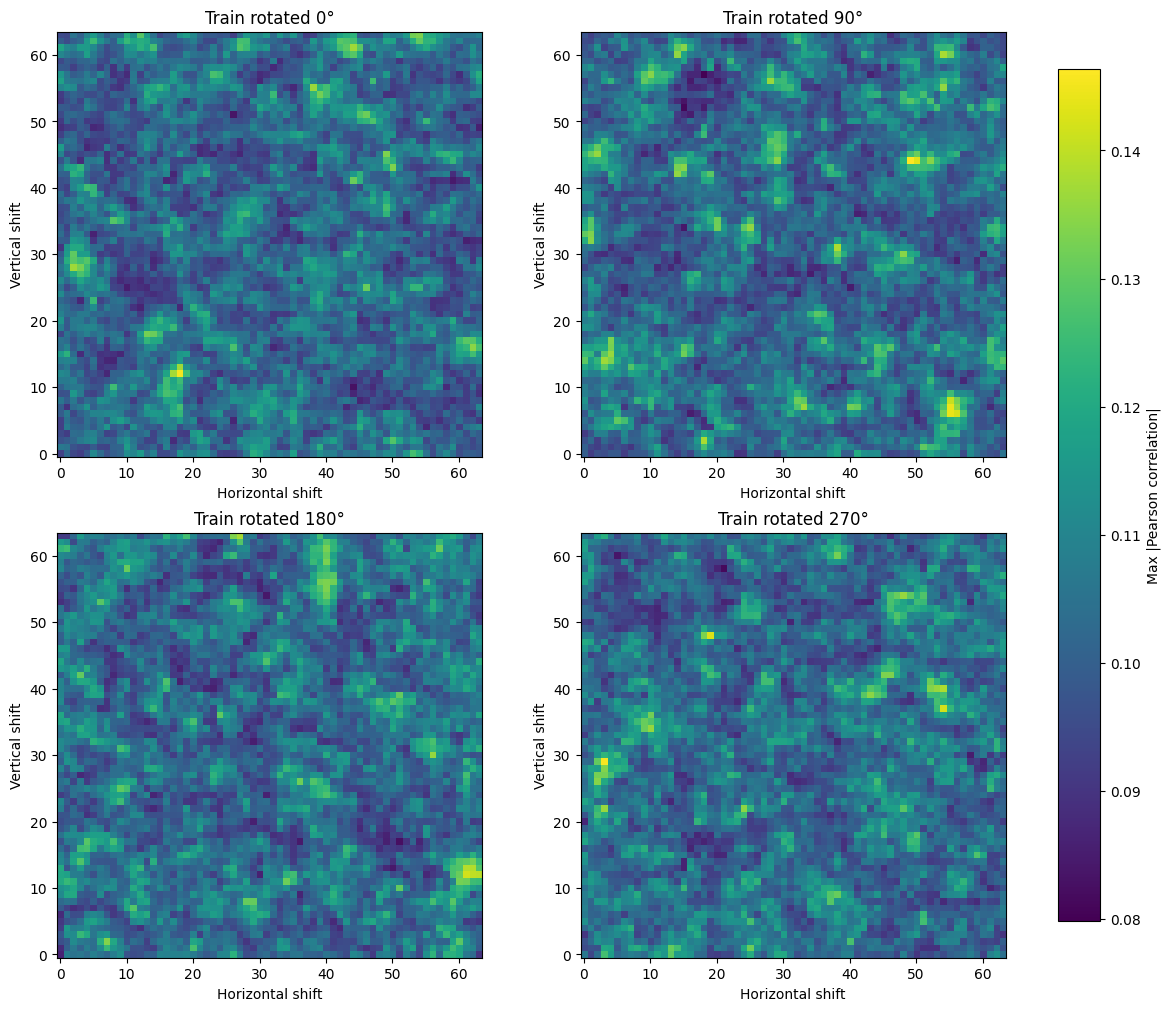

In [42]:
# ----------------------------------------------------------------------
# Visualise all four rotation heatmaps in the same image (warning‑free)
# ----------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

rotations = [('0°', corr_0), ('90°', corr_90), ('180°', corr_180), ('270°', corr_270)]

vmin = min(m.min() for _, m in rotations)
vmax = max(m.max() for _, m in rotations)

for ax, (label, matrix) in zip(axes.flat, rotations):
    im = ax.imshow(matrix, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)
    ax.set_title(f'Train rotated {label}')
    ax.set_xlabel('Horizontal shift')
    ax.set_ylabel('Vertical shift')

# Add a single colour bar that respects constrained_layout
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.92, label='Max |Pearson correlation|')

plt.show()

🔍 Top entry |corr|: stored=0.146376, recomputed=0.146376, equal=True


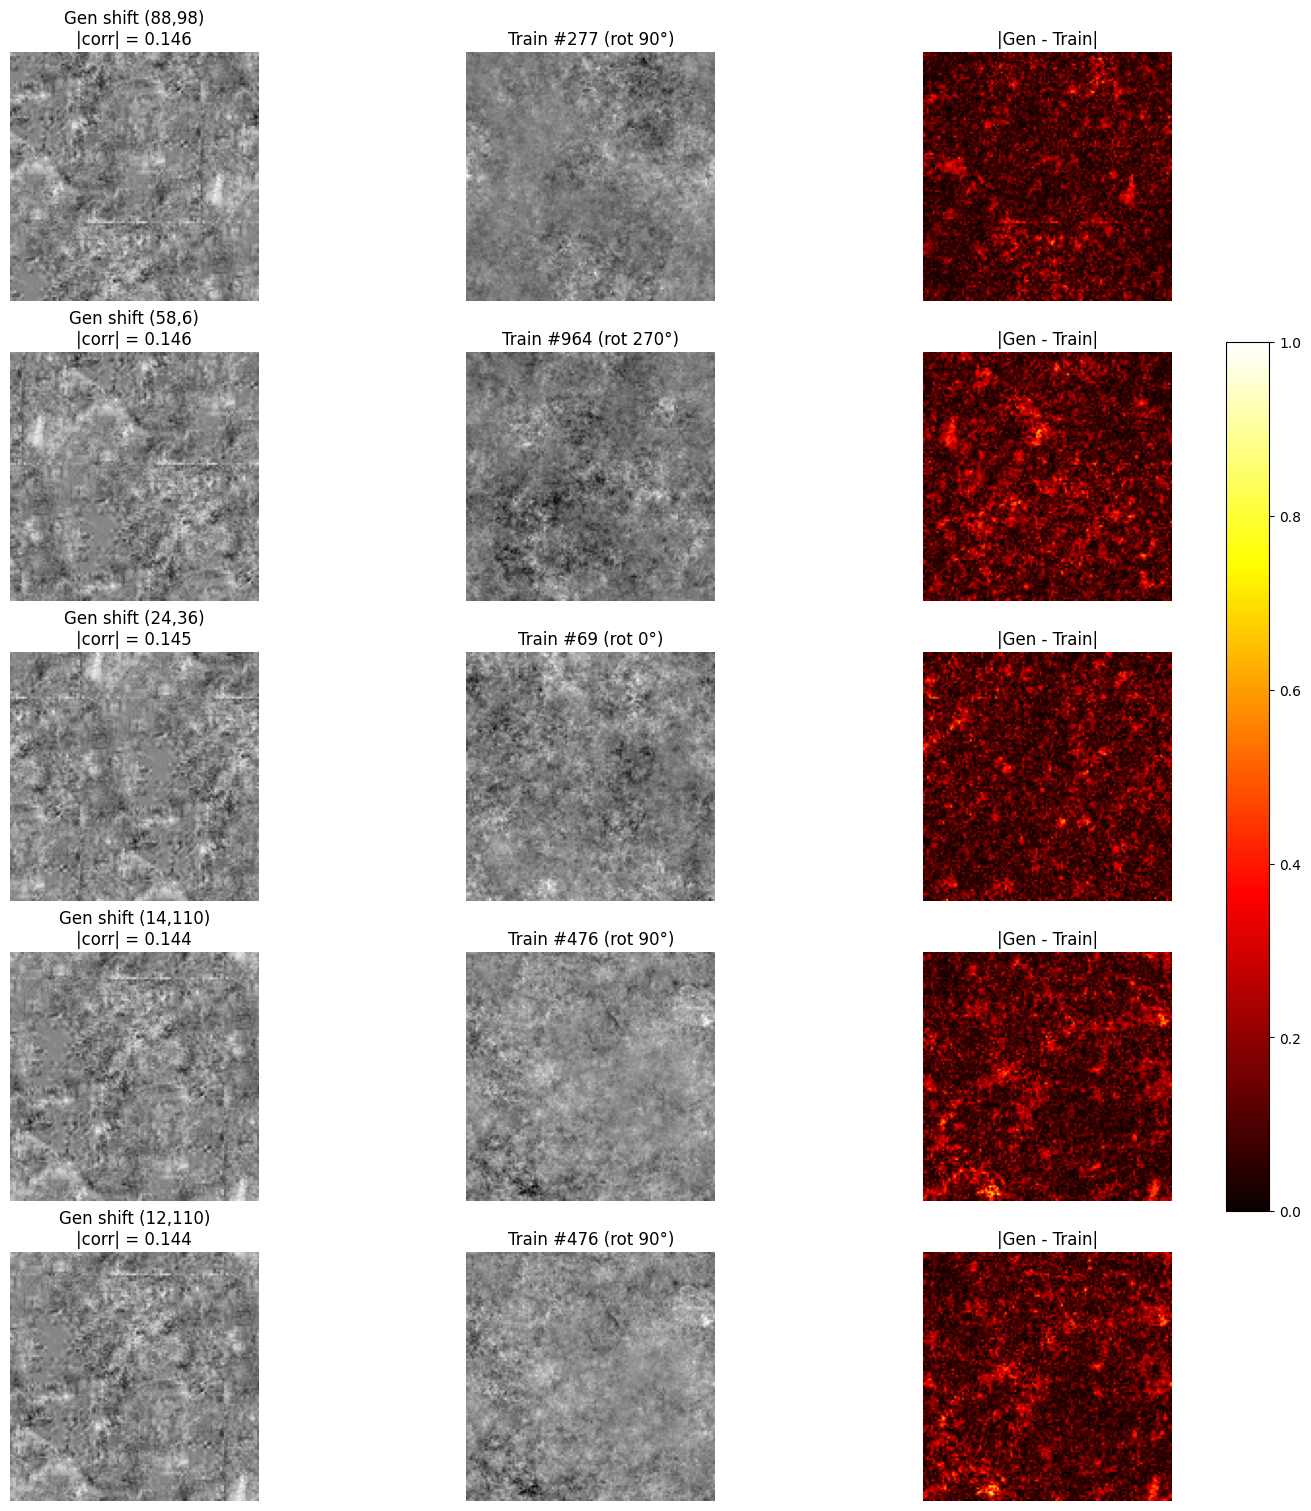


Top 3 most similar across all rotations:
Rank 1: rotation 90°, shift (88,98), |corr| = 0.1464, best training image #277
Rank 2: rotation 270°, shift (58,6), |corr| = 0.1458, best training image #964
Rank 3: rotation 0°, shift (24,36), |corr| = 0.1454, best training image #69
Rank 4: rotation 90°, shift (14,110), |corr| = 0.1445, best training image #476
Rank 5: rotation 90°, shift (12,110), |corr| = 0.1441, best training image #476


In [43]:
# ----------------------------------------------------------------------
# 5. Find top‑3 entries across ALL rotations and display (fully verified)
# ----------------------------------------------------------------------
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
n_top = 5
all_corr = [corr_0, corr_90, corr_180, corr_270]
all_best_idx = [best_idx_0, best_idx_90, best_idx_180, best_idx_270]
rotation_angles = [0, 90, 180, 270]

corr_stack = np.stack(all_corr, axis=0)           # (4, 64, 64)
flat_indices = np.argsort(corr_stack.ravel())[::-1]
top3_global = flat_indices[:n_top]

# Build rotated training image lists (same order as flat versions)
rotations_k = {0: 0, 90: 1, 180: 2, 270: 3}
train_imgs_rot = {}
for angle, k in rotations_k.items():
    train_imgs_rot[angle] = [np.rot90(img, k=k) for img in train_imgs]   # list of (128,128)

# ---- Self‑check: recompute top correlation ----
top_flat = top3_global[0]
rot_idx0, i0, j0 = np.unravel_index(top_flat, corr_stack.shape)
angle0 = rotation_angles[rot_idx0]
dy0, dx0 = shifts[i0], shifts[j0]
best_idx0 = all_best_idx[rot_idx0][i0, j0]

gen_flat = np.roll(np.roll(gen_ch1, shift=dy0, axis=0), shift=dx0, axis=1).ravel()

if angle0 == 0:
    train_flat_used = train_flat[best_idx0]
else:
    train_flat_used = train_flat_rot[angle0][best_idx0]
    
r_check, _ = pearsonr(gen_flat, train_flat_used)
print(f"🔍 Top entry |corr|: stored={corr_stack[rot_idx0,i0,j0]:.6f}, recomputed={abs(r_check):.6f}, equal={np.isclose(abs(r_check), corr_stack[rot_idx0,i0,j0])}")

from matplotlib.colors import LinearSegmentedColormap
cmap_black_red = LinearSegmentedColormap.from_list('black_red',
                                                   [(0, 0, 0), (1.0, 0.7, 0.7)],
                                                   N=256)
cmap_black_red = 'hot'

def to_01(img):
    """Convert tensor/array to numpy [0,1] float."""
    if torch.is_tensor(img):
        img = img.detach().cpu().numpy()
    img = img.astype(np.float64)
    img_min, img_max = img.min(), img.max()
    if img_max > img_min:
        img = (img - img_min) / (img_max - img_min)
    return img

# ---- Display top‑5 with fixed difference scale ----
fig, axes = plt.subplots(n_top, 3, figsize=(15, n_top * 3), constrained_layout=True)
for rank, flat_idx in enumerate(top3_global):
    rot_idx, i, j = np.unravel_index(flat_idx, corr_stack.shape)
    corr_val = corr_stack[rot_idx, i, j]
    angle = rotation_angles[rot_idx]
    best_train_idx = all_best_idx[rot_idx][i, j]
    dy, dx = shifts[i], shifts[j]

    rolled = np.roll(np.roll(gen_ch1, shift=dy, axis=0), shift=dx, axis=1)
    train_patch = train_imgs_rot[angle][best_train_idx]

    # Normalise both images to [0,1]
    rolled_np = to_01(rolled)
    train_np  = to_01(train_patch)

    # Absolute difference – now in [0,1]
    diff_abs = np.abs(rolled_np - train_np)

    # --- Plotting ---
    ax_gen = axes[rank, 0]
    ax_gen.imshow(rolled_np, cmap='gray', vmin=0, vmax=1)
    ax_gen.set_title(f'Gen shift ({dy},{dx})\n|corr| = {corr_val:.3f}')
    ax_gen.axis('off')

    ax_train = axes[rank, 1]
    ax_train.imshow(train_np, cmap='gray', vmin=0, vmax=1)
    ax_train.set_title(f'Train #{best_train_idx} (rot {angle}°)')
    ax_train.axis('off')

    ax_diff = axes[rank, 2]
    im = ax_diff.imshow(diff_abs, cmap=cmap_black_red, vmin=0, vmax=1)
    ax_diff.set_title('|Gen - Train|')
    ax_diff.axis('off')

# Add one colorbar for the whole figure (using the last `im` or any)
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, pad=0.04)
plt.show()

# Print summary
print("\nTop 3 most similar across all rotations:")
for rank, flat_idx in enumerate(top3_global):
    rot_idx, i, j = np.unravel_index(flat_idx, corr_stack.shape)
    angle = rotation_angles[rot_idx]
    dy, dx = shifts[i], shifts[j]
    print(f"Rank {rank+1}: rotation {angle}°, shift ({dy},{dx}), "
          f"|corr| = {corr_stack[rot_idx,i,j]:.4f}, best training image #{all_best_idx[rot_idx][i,j]}")

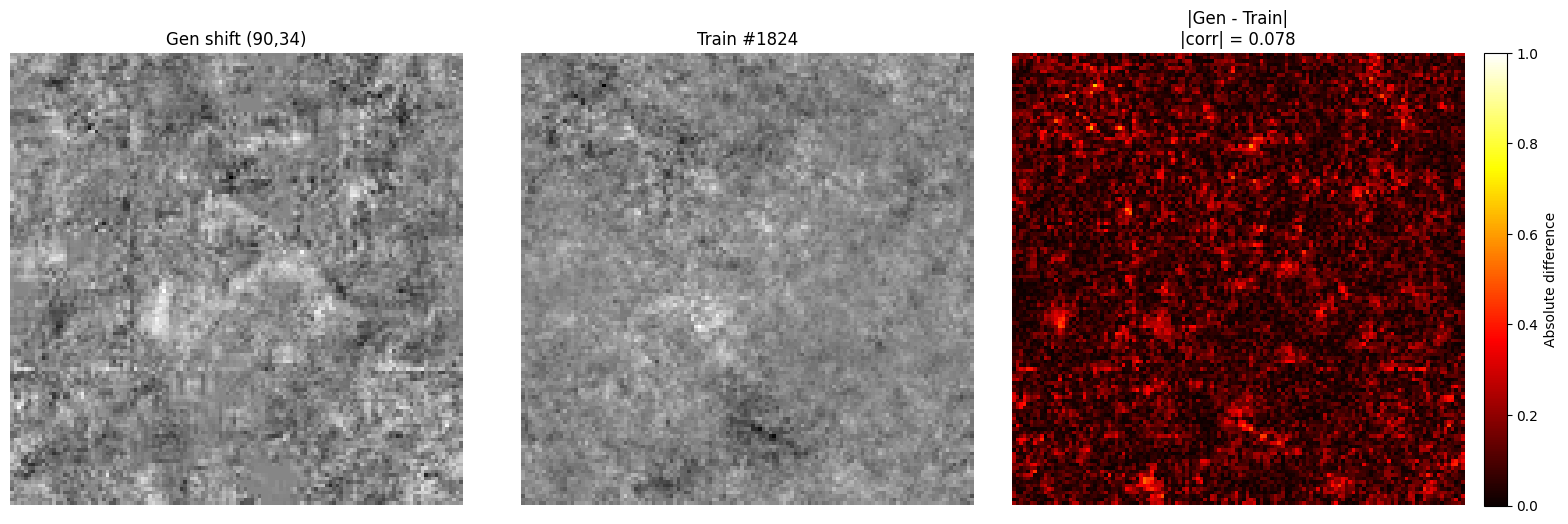

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import random
from scipy.stats import pearsonr
from matplotlib.colors import LinearSegmentedColormap

# Normalisation helper
def to_01(img):
    """Convert tensor/array to numpy [0,1] float."""
    if torch.is_tensor(img):
        img = img.detach().cpu().numpy()
    img = img.astype(np.float64)
    img_min, img_max = img.min(), img.max()
    if img_max > img_min:
        img = (img - img_min) / (img_max - img_min)
    return img

# ------------------------------------------------------------------
# 1. Pick random shift and training image
# ------------------------------------------------------------------
i_rand = random.randint(0, len(shifts)-1)
j_rand = random.randint(0, len(shifts)-1)
dy, dx = shifts[i_rand], shifts[j_rand]

rand_train_idx = random.randint(0, len(train_imgs)-1)
train_img = train_imgs[rand_train_idx]          # could be tensor or numpy

# ------------------------------------------------------------------
# 2. Create shifted generated image (as numpy)
# ------------------------------------------------------------------
if torch.is_tensor(gen_ch1):
    gen_ch1_np = gen_ch1.detach().cpu().numpy()
else:
    gen_ch1_np = gen_ch1

rolled = np.roll(np.roll(gen_ch1_np, shift=dy, axis=0), shift=dx, axis=1)

# ------------------------------------------------------------------
# 3. Normalise both images to [0,1]
# ------------------------------------------------------------------
rolled_np = to_01(rolled)
train_np  = to_01(train_img)

# ------------------------------------------------------------------
# 4. Correlation & absolute difference
# ------------------------------------------------------------------
r, _ = pearsonr(rolled_np.ravel(), train_np.ravel())
abs_r = abs(r)

diff_abs = np.abs(rolled_np - train_np)   # now in [0,1]

# ------------------------------------------------------------------
# 5. Plot with consistent 0–1 scale
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Generated
axes[0].imshow(rolled_np, cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f'Gen shift ({dy},{dx})')
axes[0].axis('off')

# Panel 2: Training
axes[1].imshow(train_np, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'Train #{rand_train_idx}')
axes[1].axis('off')

# Panel 3: Absolute difference (fixed 0–1 colour scale)
im = axes[2].imshow(diff_abs, cmap=cmap_black_red, vmin=0, vmax=1)
axes[2].set_title(f'|Gen - Train|\n|corr| = {abs_r:.3f}')
axes[2].axis('off')

cbar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
cbar.set_label('Absolute difference', fontsize=10)

plt.tight_layout()
plt.show()

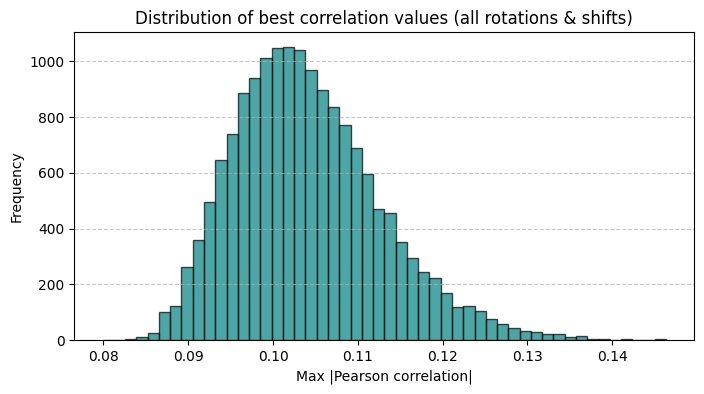

Correlation stats: min=0.080, max=0.146, mean=0.104, median=0.103


In [45]:
# ----------------------------------------------------------------------
# (Optional) Histogram of all correlation values (pooled across rotations)
# ----------------------------------------------------------------------
plt.figure(figsize=(8, 4))
# Flatten the stacked 4×64x64 array to get every single best correlation found
all_vals = corr_stack.ravel()   # 4 * 3136 values
plt.hist(all_vals, bins=50, color='teal', edgecolor='black', alpha=0.7)
plt.xlabel('Max |Pearson correlation|')
plt.ylabel('Frequency')
plt.title('Distribution of best correlation values (all rotations & shifts)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Correlation stats: min={all_vals.min():.3f}, max={all_vals.max():.3f}, "
      f"mean={all_vals.mean():.3f}, median={np.median(all_vals):.3f}")